# Direct Chart-Claim Logistic Regression

This notebook trains a lightweight logistic-regression baseline for the supervised task: chart image + scientific claim -> entailed/refuted. It uses only pair records where `modality == "chart"` and `claim_type == "direct"`. Labels are used only as targets, never as embedded text features.

## 1. Setup

The imports are grouped by purpose: data handling, optional Qdrant fallback loading, numeric feature construction, and scikit-learn modeling/evaluation. Paths are resolved robustly so the notebook works from the repo root or from `notebooks/`.

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from qdrant_client import QdrantClient
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Resolve the repo root for both interactive notebook use and nbconvert execution.
cwd = Path.cwd().resolve()
REPO_ROOT = cwd if (cwd / "sciver_vector_db").exists() else cwd.parent
sys.path.insert(0, str(REPO_ROOT))

from sciver_vector_db.qdrant_store import scroll_all

# Some local BLAS/scikit-learn builds emit benign matmul RuntimeWarnings during logistic-regression fitting.
# Keep the notebook output focused while still allowing other warning categories to surface.
warnings.filterwarnings("ignore", message=".*encountered in matmul", category=RuntimeWarning)

# Prefer the exported parquet for quick iteration; fall back to Qdrant if needed.
FEATURES_PARQUET = REPO_ROOT / "data/processed/sciver_pair_features.parquet"
QDRANT_PATH = REPO_ROOT / "data/processed/qdrant_sciver"
if not QDRANT_PATH.exists() and (REPO_ROOT / ".qdrant_sciver").exists():
    QDRANT_PATH = REPO_ROOT / ".qdrant_sciver"
COLLECTION = "sciver_pairs"

print(f"Repo root: {REPO_ROOT}")
print(f"Feature parquet: {FEATURES_PARQUET}")
print(f"Qdrant path: {QDRANT_PATH}")

Repo root: /Users/conglongxu/Projects/Erdos-2016-Summer/codebase
Feature parquet: /Users/conglongxu/Projects/Erdos-2016-Summer/codebase/data/processed/sciver_pair_features.parquet
Qdrant path: /Users/conglongxu/Projects/Erdos-2016-Summer/codebase/data/processed/qdrant_sciver


## 2. Load Pair Features

The exported parquet contains one row per chart-claim pair plus vector columns. If the parquet is missing, the code scrolls Qdrant directly with vectors and builds the same DataFrame in memory.

In [2]:
VECTOR_COLUMNS = ["claim_vec", "evidence_text_vec", "pair_text_vec", "image_vec"]

if FEATURES_PARQUET.exists():
    # Fast path: use the exported feature table generated by scripts/export_pair_features.py.
    df = pd.read_parquet(FEATURES_PARQUET)
    source = "parquet"
else:
    if not QDRANT_PATH.exists():
        raise FileNotFoundError("Neither exported parquet nor local Qdrant database was found.")

    # Fallback path: read all points from Qdrant, including named vectors.
    client = QdrantClient(path=str(QDRANT_PATH))
    rows = []
    for point in scroll_all(client, COLLECTION, with_vectors=True):
        row = dict(point.payload or {})
        vectors = point.vector or {}
        for name in VECTOR_COLUMNS:
            row[name] = vectors.get(name)
        rows.append(row)
    df = pd.DataFrame(rows)
    source = "qdrant"

print(f"Loaded {len(df):,} rows from {source}.")
df[["split", "label", "label_id", "claim_type", "modality"]].head()

Loaded 1,500 rows from parquet.


,split,label,label_id,claim_type,modality
0,val,entailed,1,direct,table
1,test,refuted,0,analytical,table
2,val,entailed,1,analytical,chart
3,test,refuted,0,analytical,table
4,val,refuted,0,analytical,table


## 3. Filter to Direct Chart Pairs

This baseline focuses on the canonical chart-claim pair unit and only uses direct claims. Records with missing vector columns are removed because scikit-learn expects a dense numeric feature matrix.

In [3]:
required_columns = ["modality", "claim_type", "label_id", "split", "label", *VECTOR_COLUMNS]
missing_columns = [column for column in required_columns if column not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Select direct chart examples and keep only rows with all vectors present.
direct_chart = df[
    (df["modality"] == "chart")
    & (df["claim_type"] == "direct")
    & df["label_id"].notna()
].copy()
for column in VECTOR_COLUMNS:
    direct_chart = direct_chart[direct_chart[column].notna()]

if direct_chart.empty:
    raise RuntimeError("No direct chart records with complete vectors were found.")

print(f"Direct chart records: {len(direct_chart):,}")
print("\nCounts by split and label:")
display(direct_chart.groupby(["split", "label"]).size().rename("count").reset_index())

Direct chart records: 416

Counts by split and label:


,split,label,count
0,test,entailed,137
1,test,refuted,139
2,val,entailed,76
3,val,refuted,64


## 4. Build the Feature Matrix

The classifier uses all available pair-level vectors: claim text, evidence text, paired claim/evidence text, and image embeddings. It also adds two simple text-vector interaction features: absolute difference and elementwise product between `claim_vec` and `evidence_text_vec`.

In [4]:
def stack_vector_column(frame, column):
    """Convert a DataFrame vector column of lists/arrays into a dense 2D NumPy array."""
    vectors = [np.asarray(value, dtype=np.float32) for value in frame[column]]
    lengths = {vector.shape[0] for vector in vectors}
    if len(lengths) != 1:
        raise ValueError(f"Column {column} has inconsistent vector lengths: {sorted(lengths)}")
    return np.vstack(vectors)

claim_vec = stack_vector_column(direct_chart, "claim_vec")
evidence_text_vec = stack_vector_column(direct_chart, "evidence_text_vec")
pair_text_vec = stack_vector_column(direct_chart, "pair_text_vec")
image_vec = stack_vector_column(direct_chart, "image_vec")

# Interaction terms are valid because claim_vec and evidence_text_vec use the same text model/dimension.
claim_evidence_absdiff = np.abs(claim_vec - evidence_text_vec)
claim_evidence_product = claim_vec * evidence_text_vec

feature_blocks = {
    "claim_vec": claim_vec,
    "evidence_text_vec": evidence_text_vec,
    "pair_text_vec": pair_text_vec,
    "image_vec": image_vec,
    "abs_claim_minus_evidence": claim_evidence_absdiff,
    "claim_times_evidence": claim_evidence_product,
}
X = np.hstack(list(feature_blocks.values())).astype(np.float64)
# Keep the matrix safe for scikit-learn even if a future export contains a non-finite value.
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
y = direct_chart["label_id"].astype(int).to_numpy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
pd.DataFrame({name: [block.shape[1]] for name, block in feature_blocks.items()}, index=["n_features"])

X shape: (416, 2432)
y shape: (416,)


,claim_vec,evidence_text_vec,pair_text_vec,image_vec,abs_claim_minus_evidence,claim_times_evidence
n_features,384,384,384,512,384,384


## 5. Create a Train/Test Split

The preferred evaluation is split-aware: train on validation records and evaluate on test records. If the validation subset is too small or contains only one class, the notebook falls back to a stratified split within the filtered direct-chart subset and prints that choice.

In [5]:
splits = direct_chart["split"].to_numpy()
train_mask = splits == "val"
test_mask = splits == "test"

use_dataset_split = (
    train_mask.sum() > 0
    and test_mask.sum() > 0
    and len(np.unique(y[train_mask])) == 2
    and len(np.unique(y[test_mask])) == 2
)

if use_dataset_split:
    # Keep SciVer's original validation/test separation for evaluation.
    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]
    split_note = "Using original split: train=val, test=test."
else:
    # Fallback keeps class proportions when original splits are not viable for this subset.
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=42,
        stratify=y if len(np.unique(y)) == 2 else None,
    )
    split_note = "Using fallback stratified random split because original split was not viable."

print(split_note)
print(f"Train size: {len(y_train):,}; label counts: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Test size:  {len(y_test):,}; label counts: {dict(zip(*np.unique(y_test, return_counts=True)))}")

Using original split: train=val, test=test.
Train size: 140; label counts: {np.int64(0): np.int64(64), np.int64(1): np.int64(76)}
Test size:  276; label counts: {np.int64(0): np.int64(139), np.int64(1): np.int64(137)}


## 6. Train Logistic Regression

Logistic regression is a lightweight baseline that works directly on dense vector features. The pipeline standardizes features first and then trains a balanced logistic-regression classifier.

In [6]:
model = Pipeline(
    steps=[
        # Scaling is important because image/text vectors and interaction features can have different ranges.
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
    ]
)

model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


## 7. Evaluate the Baseline

Accuracy reports raw correctness. Balanced accuracy averages per-class recall, which is useful when entailed/refuted counts differ. The confusion matrix shows where the classifier confuses the two classes.

Accuracy:          0.547
Balanced accuracy: 0.547

Classification report:
              precision    recall  f1-score   support

     refuted       0.55      0.54      0.55       139
    entailed       0.54      0.55      0.55       137

    accuracy                           0.55       276
   macro avg       0.55      0.55      0.55       276
weighted avg       0.55      0.55      0.55       276



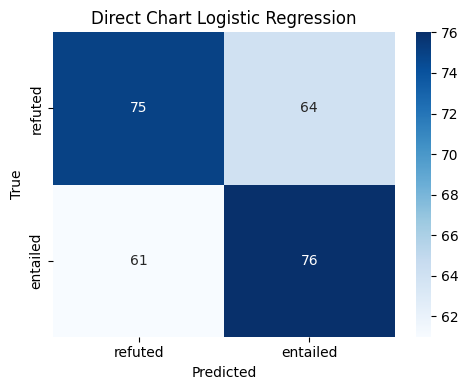

In [7]:
y_pred = model.predict(X_test)

print(f"Accuracy:          {accuracy_score(y_test, y_pred):.3f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred):.3f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["refuted", "entailed"]))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["refuted", "entailed"], yticklabels=["refuted", "entailed"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Direct Chart Logistic Regression")
plt.tight_layout()
plt.show()

## 8. Inspect Feature Block Coefficients

The coefficient norm by feature block gives a rough sense of which vector groups the linear model uses most. This is not a causal explanation, but it is a quick diagnostic for feature-store experiments.

In [8]:
classifier = model.named_steps["classifier"]
coef = classifier.coef_.ravel()

rows = []
start = 0
for name, block in feature_blocks.items():
    end = start + block.shape[1]
    block_coef = coef[start:end]
    rows.append({"feature_block": name, "n_features": block.shape[1], "coef_l2_norm": np.linalg.norm(block_coef)})
    start = end

# Larger norms indicate blocks that received larger linear weights after standardization.
pd.DataFrame(rows).sort_values("coef_l2_norm", ascending=False).reset_index(drop=True)

,feature_block,n_features,coef_l2_norm
0,abs_claim_minus_evidence,384,0.966865
1,image_vec,512,0.903244
2,pair_text_vec,384,0.704211
3,claim_vec,384,0.679809
4,claim_times_evidence,384,0.679692
5,evidence_text_vec,384,0.000000
